# TAG Variants Score Analysis


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
import itertools
import statsmodels.stats.multitest as smm
import seaborn as sns
import matplotlib.pyplot as plt


## Load Data


In [2]:
data = pd.read_csv("master_decision_results.csv")

variant = data["Variant_ID"].astype("category")
t1score = data["Top1"]


## Split scores by variant


In [3]:
t1score_vectors = {
    v: group["Top1"].values
    for v, group in data.groupby("Variant_ID")
}


## Normality check (Shapiro-Wilk)


In [12]:
shapiro_results = {
    v: shapiro(scores)
    for v, scores in t1score_vectors.items()
}

#shapiro_results

In [9]:
shapiro_table = pd.DataFrame([
    {
        "Variant": v,
        "W_stat": result.statistic,
        "p_value": result.pvalue,
        "Significant (p<0.05)": result.pvalue < 0.05
    }
    for v, result in shapiro_results.items()
])

shapiro_table = shapiro_table.sort_values("p_value")

shapiro_table

,Variant,W_stat,p_value,Significant (p<0.05)
5,1_8_10_e,0.825572,0.000393,True
7,1_8_11_e,0.919955,0.001488,True
6,1_8_11_a,0.921041,0.001636,True
4,1_8_10_a,0.864904,0.002305,True
3,1_7_11_e,0.962095,0.085533,False
2,1_7_11_a,0.972531,0.248611,False
1,1_7_10_e,0.962763,0.426268,False
0,1_7_10_a,0.971839,0.650988,False


## Pairwise Wilcoxon (Mann–Whitney U)


In [5]:
variants = list(t1score_vectors.keys())
pairs = list(itertools.combinations(variants, 2))

p_values = []
results = []

for v1, v2 in pairs:
    stat, p = mannwhitneyu(
        t1score_vectors[v1],
        t1score_vectors[v2],
        alternative='two-sided'
    )
    p_values.append(p)
    results.append((v1, v2, p))


## Benjamini-Hochberg correction


In [11]:
reject, pvals_corrected, _, _ = smm.multipletests(
    p_values, method='fdr_bh'
)

pairwise_results = [
    (v1, v2, p, p_corr, r)
    for (v1, v2, p), p_corr, r in zip(results, pvals_corrected, reject)
]

#pairwise_results


In [10]:
pairwise_table = pd.DataFrame([
    {
        "Variant 1": v1,
        "Variant 2": v2,
        "Raw p-value": p,
        "BH corrected p-value": p_corr,
        "Significant (p<0.05)": r
    }
    for (v1, v2, p), p_corr, r in zip(results, pvals_corrected, reject)
])

pairwise_table = pairwise_table.sort_values("BH corrected p-value")

pairwise_table

,Variant 1,Variant 2,Raw p-value,BH corrected p-value,Significant (p<0.05)
16,1_7_11_a,1_8_11_a,3.366816e-19,2.356771e-18,True
21,1_7_11_e,1_8_11_e,3.359012e-19,2.356771e-18,True
17,1_7_11_a,1_8_11_e,3.366165e-19,2.356771e-18,True
20,1_7_11_e,1_8_11_a,3.359662e-19,2.356771e-18,True
12,1_7_10_e,1_8_11_e,2.905164e-13,6.780793e-13,True
15,1_7_11_a,1_8_10_e,2.890962e-13,6.780793e-13,True
14,1_7_11_a,1_8_10_a,2.890962e-13,6.780793e-13,True
11,1_7_10_e,1_8_11_a,2.906054e-13,6.780793e-13,True
18,1_7_11_e,1_8_10_a,2.881235e-13,6.780793e-13,True
6,1_7_10_a,1_8_11_e,2.905164e-13,6.780793e-13,True


## Visualization (Boxplot)


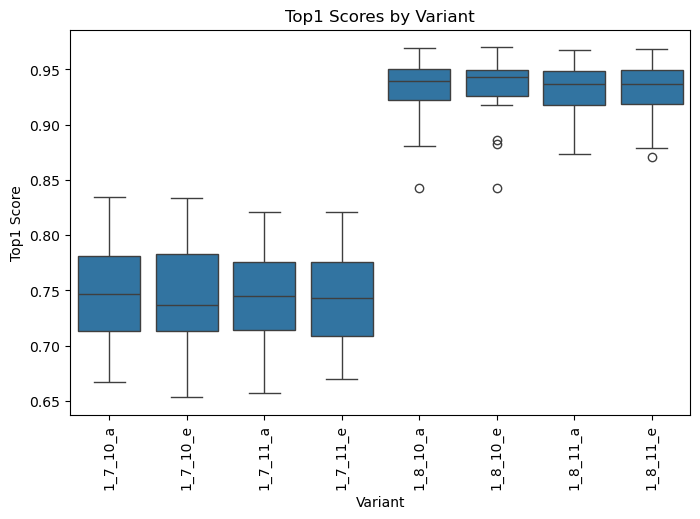

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="Variant_ID", y="Top1")

plt.title("Top1 Scores by Variant")
plt.xlabel("Variant")
plt.ylabel("Top1 Score")

plt.xticks(rotation=90)
plt.show()
